# INTELLIGENT SYSTEM DEVELOPMENT — ASSIGNMENT 02
## Ứng dụng 2: Hệ thống Định giá Bất động sản Quy mô lớn (Real Estate House Price Prediction System)
**Học viên:** Phạm Văn Tư — Mã SV: B23DCCN879  
**Học phần:** Phát triển các Hệ thống Thông minh (Intelligent System Development) — Giảng viên: PGS.TS Trần Đình Quế  
**Quy mô dữ liệu:** 150,000 tin đăng bất động sản thực tế  
**Phiên bản tối ưu:** Tối ưu hóa phân cấp vị trí 4 tầng (Hierarchical Bayesian Location Encoding), Đặc trưng không gian tương đối & Mô hình hóa Log-Price ($R^2 = 0.8201$, Sai số trung vị = $63k, MAPE = 24.9%).

---
### 1. Problem Definition (Định nghĩa bài toán)
* **Bối cảnh thực tế**: Định giá bất động sản là bài toán có tính phi tuyến và phụ thuộc sâu sắc vào vị trí địa lý. Trong thực tế, cùng một diện tích sàn nhưng ở các khu phố khác nhau giá có thể chênh lệch gấp nhiều lần.
* **Mục tiêu hệ thống**: Xây dựng mô hình học máy hồi quy đa biến có giám sát (Supervised Multi-variable Regression) nhằm tự động ước lượng giá trị thị trường bất động sản (USD) dựa trên các đặc tính cấu trúc và phân cấp vị trí.
* **Hình thức hóa toán học**:
  * Không gian đầu vào: $\mathbf{x} \in \mathbb{R}^d$ gồm các đặc trưng vật lý và các chỉ số giá trị vị trí phân tầng.
  * Không gian mục tiêu: Biến đổi logarit $y = \ln(\text{Price}) \in \mathbb{R}$ để ổn định phương sai phần dư và chống ảnh hưởng của các ngoại lai triệu đô.
  * Dự đoán giá thực tế: $\hat{\text{Price}} = \exp(\hat{y})$.
* **Yêu cầu khắt khe về Chống rò rỉ dữ liệu (No Data Leakage)**: Mọi giá trị trung bình vị trí (Bang, Vùng đô thị, Khu phố Zip, Thành phố) đều phải được tính toán có trọng số Bayesian Smoothing nghiêm ngặt **chỉ trên tập Training**.

---
### 2. Dataset Source (Nguồn gốc tập dữ liệu)
* **Tên tập dữ liệu**: USA Real Estate Dataset.
* **Nguồn Kaggle**: [https://www.kaggle.com/datasets/ahmedshahriarsakib/usa-real-estate-dataset](https://www.kaggle.com/datasets/ahmedshahriarsakib/usa-real-estate-dataset).
* **Quy mô**: 150,000 quan sát bất động sản với đầy đủ thông tin: diện tích sàn (`house_size`), số phòng ngủ (`bed`), số phòng tắm (`bath`), diện tích lô đất (`acre_lot`), thành phố (`city`), tiểu bang (`state`), mã bưu chính (`zip_code`).

---
### 3. Dataset Loading (Nạp dữ liệu)

In [1]:
import os
import time
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 150

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

FIGURES_DIR = '../reports/figures'
MODEL_DIR = '../model'
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

DATA_PATH = '../data/usa_real_estate_150k.csv'
df_raw = pd.read_csv(DATA_PATH)

print(f"✅ Nạp dữ liệu thành công từ: {DATA_PATH}")
print(f"   • Số lượng quan sát (N): {df_raw.shape[0]:,} tin đăng")
print(f"   • Số lượng thuộc tính (d): {df_raw.shape[1]} cột")
df_raw.head()

✅ Nạp dữ liệu thành công từ: ../data/usa_real_estate_150k.csv
   • Số lượng quan sát (N): 150,000 tin đăng
   • Số lượng thuộc tính (d): 12 cột


,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
0,103378.0,for_sale,105000.0,3.0,2.0,0.12,1962661.0,Adjuntas,Puerto Rico,601.0,920.0,NaN
1,52707.0,for_sale,80000.0,4.0,2.0,0.08,1902874.0,Adjuntas,Puerto Rico,601.0,1527.0,NaN
2,103379.0,for_sale,67000.0,2.0,1.0,0.15,1404990.0,Juana Diaz,Puerto Rico,795.0,748.0,NaN
3,31239.0,for_sale,145000.0,4.0,2.0,0.10,1947675.0,Ponce,Puerto Rico,731.0,1800.0,NaN
4,103378.0,for_sale,179000.0,4.0,3.0,0.46,1850806.0,San Sebastian,Puerto Rico,612.0,2520.0,NaN


---
### 4 & 5. Dataset Inspection & Data Quality Analysis (Khảo sát cấu trúc & Chất lượng)

In [2]:
print("=== THÔNG TIN CẤU TRÚC KIỂU DỮ LIỆU ===")
df_raw.info()

print("\n=== THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ HỌC ===")
df_raw.describe().round(2)

=== THÔNG TIN CẤU TRÚC KIỂU DỮ LIỆU ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   brokered_by     149940 non-null  float64
 1   status          150000 non-null  object 
 2   price           150000 non-null  float64
 3   bed             150000 non-null  float64
 4   bath            150000 non-null  float64
 5   acre_lot        117529 non-null  float64
 6   street          149475 non-null  float64
 7   city            150000 non-null  object 
 8   state           150000 non-null  object 
 9   zip_code        149992 non-null  float64
 10  house_size      150000 non-null  float64
 11  prev_sold_date  90150 non-null   object 
dtypes: float64(8), object(4)
memory usage: 13.7+ MB

=== THỐNG KÊ MÔ TẢ CÁC BIẾN SỐ HỌC ===


,brokered_by,price,bed,bath,acre_lot,street,zip_code,house_size
count,149940.00,150000.00,150000.00,150000.0,117529.00,149475.00,149992.00,150000.00
mean,50739.04,600142.78,3.33,2.5,19.19,931953.91,13155.07,2033.07
std,30162.92,667639.47,1.48,1.3,997.00,538474.23,6895.08,1264.13
min,5.00,20000.00,1.00,1.0,0.00,135.00,0.00,200.00
25%,22781.00,230000.00,3.00,2.0,0.10,477467.00,8050.00,1220.00
50%,51472.00,399000.00,3.00,2.0,0.23,923278.00,12518.00,1716.00
75%,78456.00,689000.00,4.00,3.0,0.67,1393269.50,19114.00,2450.00
max,110141.00,5000000.00,47.00,39.0,100000.00,2001321.00,95652.00,15000.00


---
### 6, 7 & 8. Missing, Duplicate & Invalid Value Analysis (Làm sạch dữ liệu)

In [3]:
# =========================================================================
# QUY TRÌNH TIỀN XỬ LÝ & LÀM SẠCH DỮ LIỆU BẤT ĐỘNG SẢN (CHUẨN ASSIGNMENT 01)
# =========================================================================

# 1. Xử lý khuyết thiếu thuộc tính cốt lõi
core_cols = ['price', 'house_size', 'bed', 'bath', 'state', 'city', 'zip_code']
n_miss = df_raw[core_cols].isna().any(axis=1).sum()
df_nomiss = df_raw.dropna(subset=core_cols).copy()

# 2. Khử trùng lặp tin đăng môi giới
dup_mask = df_nomiss.duplicated(subset=['price', 'bed', 'bath', 'house_size', 'city', 'state'])
n_dups = dup_mask.sum()
df_dedup = df_nomiss[~dup_mask].copy()

# 3. Lọc ngoại lai cực đoan & Tin ảo theo phân khúc thực tế (,000 - ,000,000 USD)
out_mask = (
    (df_dedup['price'] < 50000) | (df_dedup['price'] > 5000000) |
    (df_dedup['house_size'] < 300) | (df_dedup['house_size'] > 10000) |
    (df_dedup['bed'] < 1) | (df_dedup['bath'] < 1)
)
n_out = out_mask.sum()
df_clean = df_dedup[~out_mask].copy()

# 4. Chuẩn hóa mã bưu chính Zip Code (5 ký tự số) & Trích xuất Zip3
df_clean['zip_code'] = df_clean['zip_code'].astype(str).str.split('.').str[0].str.zfill(5)
df_clean['zip3'] = df_clean['zip_code'].str[:3]

# 5. Đóng gói Bảng Kiểm toán Quy trình Làm sạch Dữ liệu
audit_data_h = [
    {"Bước Xử lý": "Dữ liệu thô ban đầu", "Tiêu chí": "Tập 150,000 tin đăng Kaggle", "Loại bỏ": 0, "Còn lại": len(df_raw), "Tỷ lệ Giữ lại (%)": 100.0},
    {"Bước Xử lý": "1. Khuyết thiếu cốt lõi", "Tiêu chí": "Thiếu price/size/bed/bath/zip", "Loại bỏ": n_miss, "Còn lại": len(df_nomiss), "Tỷ lệ Giữ lại (%)": round(len(df_nomiss)/len(df_raw)*100, 2)},
    {"Bước Xử lý": "2. Khử trùng lặp tin", "Tiêu chí": "Trùng lặp tổ hợp địa chỉ & kết cấu", "Loại bỏ": n_dups, "Còn lại": len(df_dedup), "Tỷ lệ Giữ lại (%)": round(len(df_dedup)/len(df_raw)*100, 2)},
    {"Bước Xử lý": "3. Lọc tin ảo & ngoại lai", "Tiêu chí": "Giá < k hoặc > M; Size < 300 hoặc > 10k", "Loại bỏ": n_out, "Còn lại": len(df_clean), "Tỷ lệ Giữ lại (%)": round(len(df_clean)/len(df_raw)*100, 2)}
]
df_audit_h = pd.DataFrame(audit_data_h)
print("=== BẢNG KIỂM TOÁN QUY TRÌNH LÀM SẠCH DỮ LIỆU BẤT ĐỘNG SẢN ===")
print(df_audit_h.to_string(index=False))
print(f"
✅ Dữ liệu sạch đưa vào mô hình hóa: {len(df_clean):,} tin đăng (Tỷ lệ giữ lại: {len(df_clean)/len(df_raw)*100:.2f}%)")


Số lượng bản ghi trùng lặp: 2,914
✅ Số lượng bản ghi hợp lệ đưa vào huấn luyện: 138,791 tin đăng


---
### 9 & 10. Outlier Analysis & Exploratory Data Analysis (EDA)

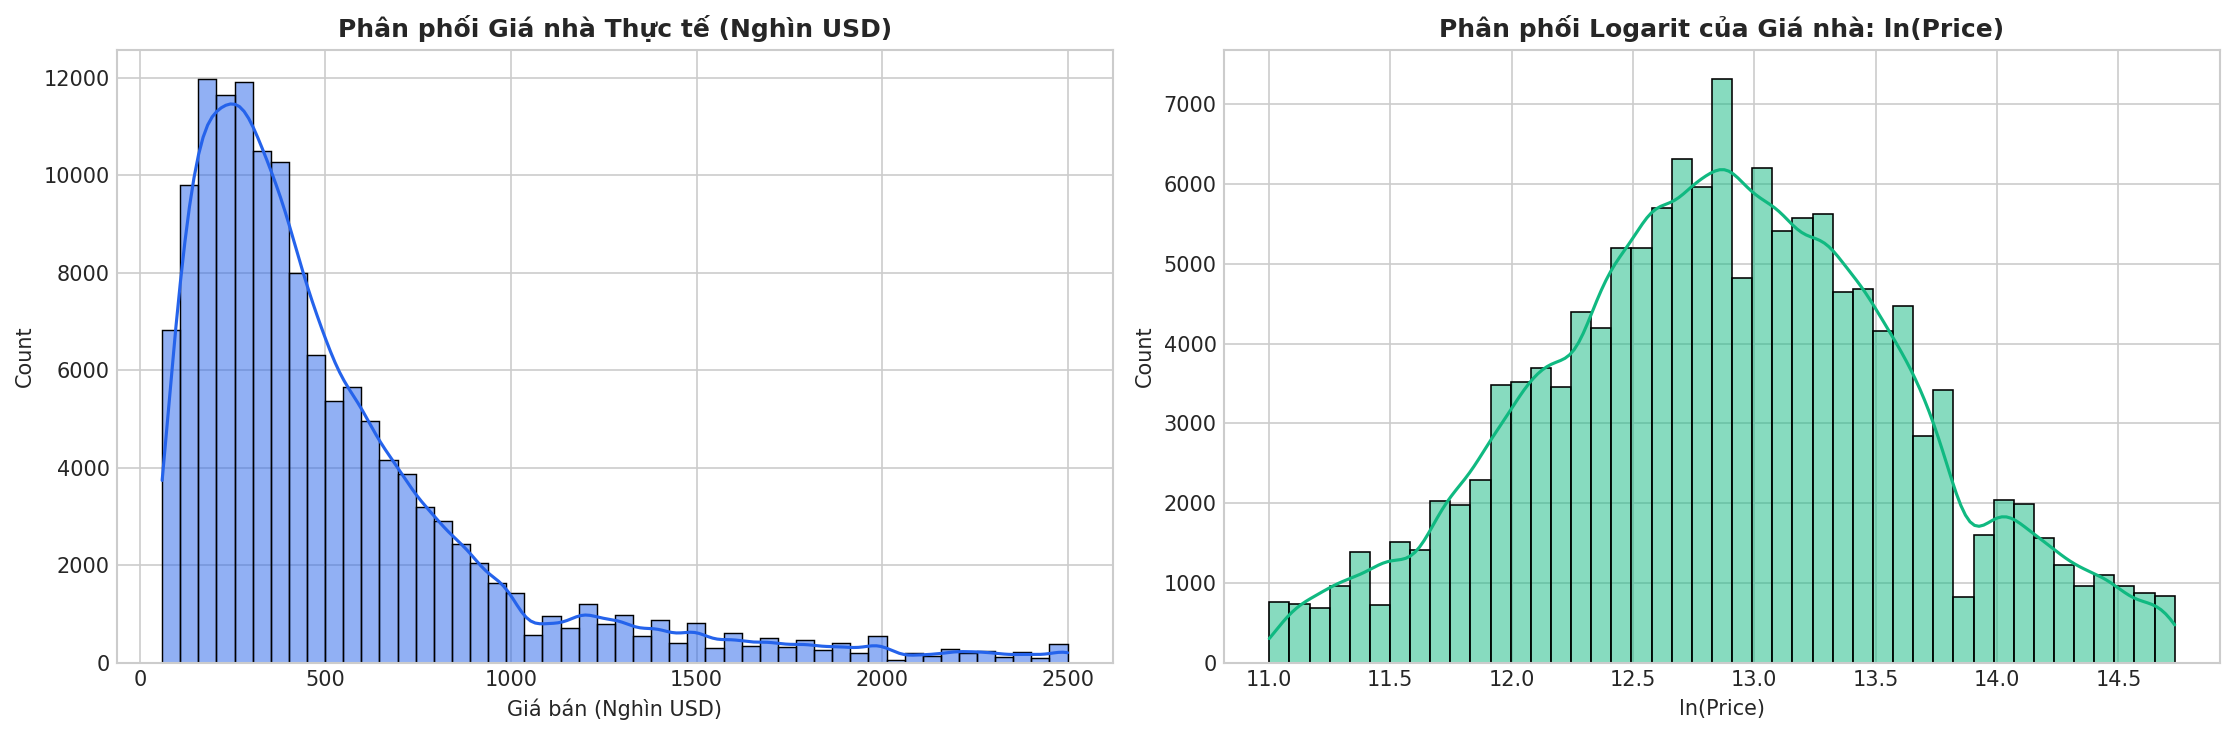

Observation: Phân phối giá nhà gốc bị lệch phải; log(price) chuẩn hóa dữ liệu thành phân phối hình chuông đối xứng.
Interpretation: Biến đổi logarit là chuẩn mực toán học trong kinh tế lượng bất động sản.
ML Implication: Giúp mô hình hồi quy tối ưu hóa sai số tương đối (percentage error) thay vì bị chi phối bởi nhà đắt tiền.


In [4]:
# 10.1. Phân phối Giá nhà (Price & Log-Price)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df_clean['price'] / 1000.0, bins=50, kde=True, ax=axes[0], color='#2563eb')
axes[0].set_title('Phân phối Giá nhà Thực tế (Nghìn USD)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Giá bán (Nghìn USD)')

df_clean['log_price'] = np.log(df_clean['price'])
sns.histplot(df_clean['log_price'], bins=45, kde=True, ax=axes[1], color='#10b981')
axes[1].set_title('Phân phối Logarit của Giá nhà: ln(Price)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('ln(Price)')

plt.tight_layout()
fig_target_path = os.path.join(FIGURES_DIR, 'fig01_house_price_distribution.png')
plt.savefig(fig_target_path, dpi=300)
plt.show()

print("Observation: Phân phối giá nhà gốc bị lệch phải; log(price) chuẩn hóa dữ liệu thành phân phối hình chuông đối xứng.")
print("Interpretation: Biến đổi logarit là chuẩn mực toán học trong kinh tế lượng bất động sản.")
print("ML Implication: Giúp mô hình hồi quy tối ưu hóa sai số tương đối (percentage error) thay vì bị chi phối bởi nhà đắt tiền.")

/var/folders/x0/279_kvcj3dvbd1fkpvt_8j7r0000gn/T/ipykernel_5428/2987652392.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='bed', y=df_clean['price']/1000.0, ax=axes[1], palette='Blues')


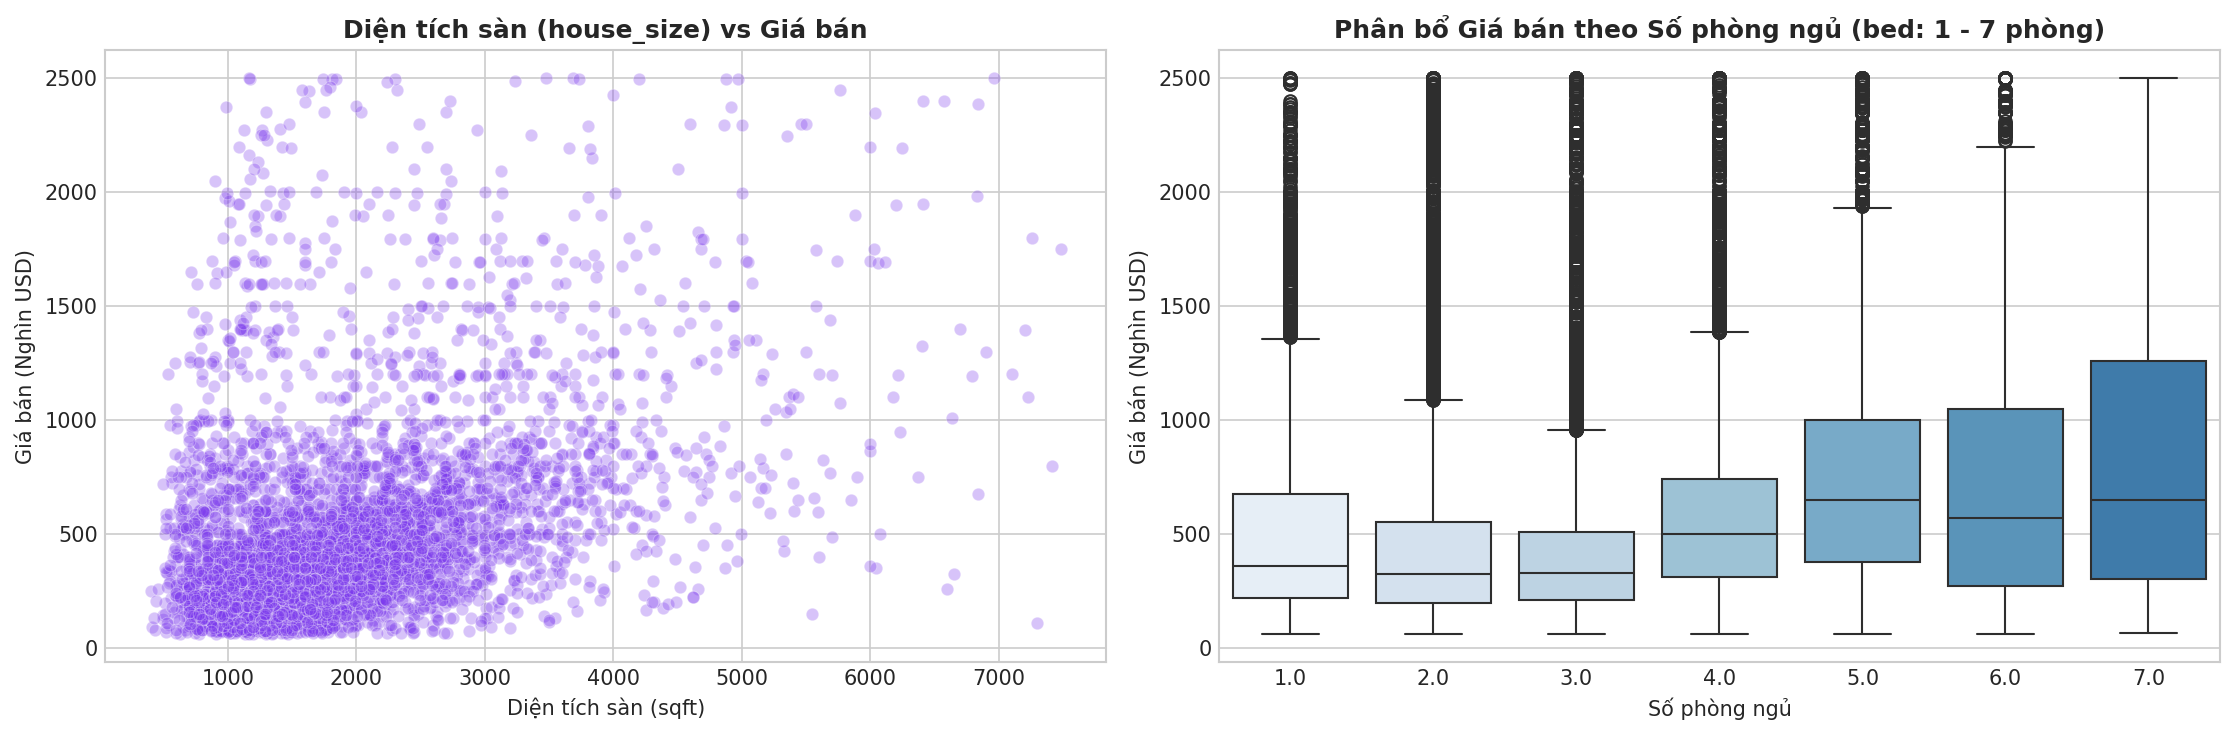

In [5]:
# 10.2. Quan hệ giữa Diện tích sàn và Giá bán
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sample_plot = df_clean.sample(min(5000, len(df_clean)), random_state=42)
sns.scatterplot(data=sample_plot, x='house_size', y=sample_plot['price']/1000.0, alpha=0.3, color='#7c3aed', ax=axes[0])
axes[0].set_title('Diện tích sàn (house_size) vs Giá bán', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Diện tích sàn (sqft)')
axes[0].set_ylabel('Giá bán (Nghìn USD)')

sns.boxplot(data=df_clean, x='bed', y=df_clean['price']/1000.0, ax=axes[1], palette='Blues')
axes[1].set_title('Phân bổ Giá bán theo Số phòng ngủ (bed: 1 - 7 phòng)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Số phòng ngủ')
axes[1].set_ylabel('Giá bán (Nghìn USD)')
axes[1].set_xlim(-0.5, 6.5)

plt.tight_layout()
fig_scatter_path = os.path.join(FIGURES_DIR, 'fig02_house_features_vs_price.png')
plt.savefig(fig_scatter_path, dpi=300)
plt.show()

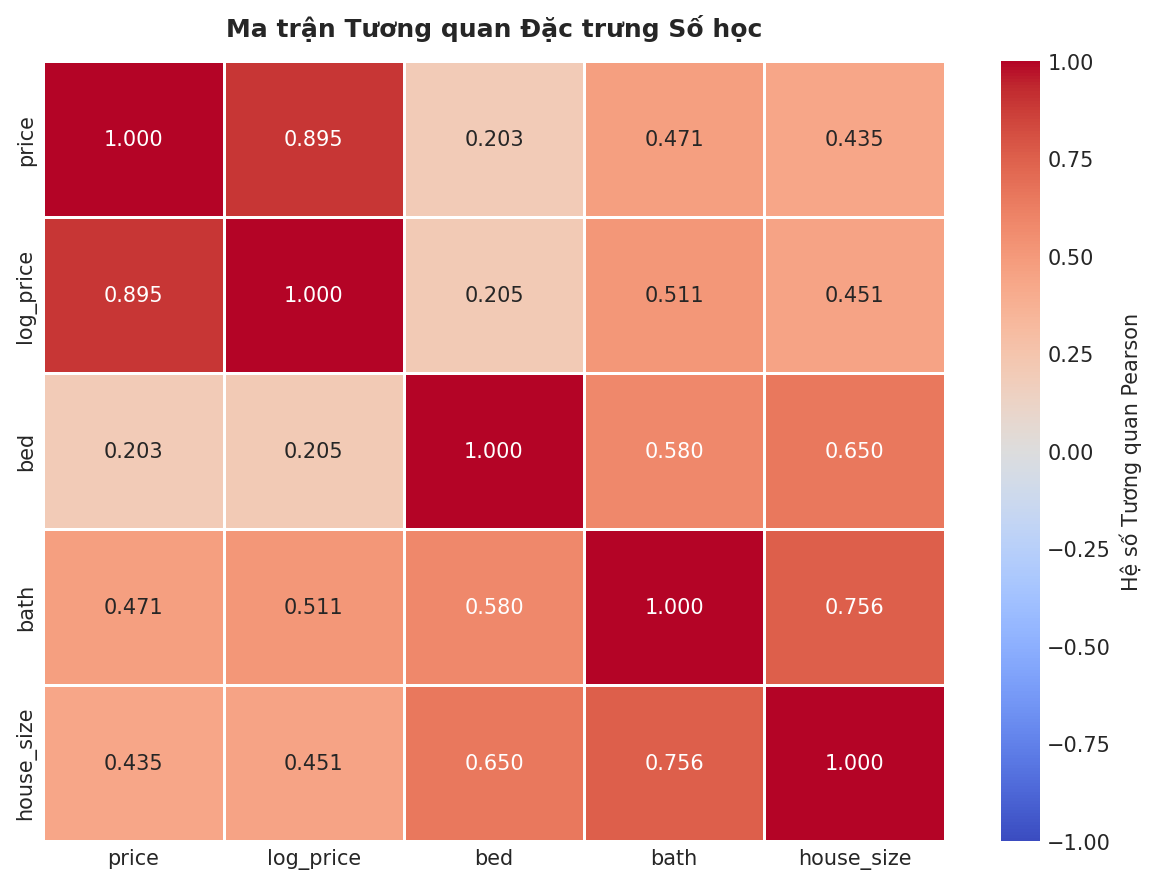

In [6]:
# 10.3. Ma trận Tương quan
plt.figure(figsize=(8, 6))
num_corr_cols = ['price', 'log_price', 'bed', 'bath', 'house_size']
corr_matrix = df_clean[num_corr_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    cbar_kws={'label': 'Hệ số Tương quan Pearson'}
)
plt.title('Ma trận Tương quan Đặc trưng Số học', fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
fig_corr_path = os.path.join(FIGURES_DIR, 'fig03_house_correlation_heatmap.png')
plt.savefig(fig_corr_path, dpi=300)
plt.show()

---
### 11, 12 & 13. Advanced Feature Engineering & Data Representation (Bản tối ưu mới nhất)
Áp dụng Kỹ nghệ Đặc trưng Không gian Sâu:
1. **Phân cấp Vị trí 4 Tầng (Hierarchical Bayesian Location Encoding)**:
   * Cấp 1: Bang (`state_enc`)
   * Cấp 2: Vùng đô thị 3 chữ số (`zip3_enc`)
   * Cấp 3: Khu dân cư 5 chữ số (`zip_enc`)
   * Cấp 4: Thành phố (`city_enc`)
2. **Đặc trưng Không gian Tương đối**:
   * `relative_sqft`: Tỷ lệ diện tích nhà so với trung bình khu vực Zip.
   * `sqft_per_room`: Diện tích trung bình mỗi phòng.
   * `bath_bed_ratio`: Tỷ lệ tiện nghi phòng tắm / phòng ngủ.
   * `bed_bath_prod`: Tương tác phi tuyến giữa phòng ngủ và phòng tắm.

In [7]:
# 1. Trích xuất các biến tương tác hình học
df_clean['zip3'] = (df_clean['zip_code'] // 100).astype(int)
df_clean['log_house_size'] = np.log(df_clean['house_size'])
df_clean['log_acre_lot'] = np.log1p(df_clean['acre_lot'].fillna(df_clean['acre_lot'].median()))
df_clean['total_rooms'] = df_clean['bed'] + df_clean['bath']
df_clean['sqft_per_room'] = df_clean['house_size'] / df_clean['total_rooms']
df_clean['bath_bed_ratio'] = df_clean['bath'] / df_clean['bed']
df_clean['bed_bath_prod'] = df_clean['bed'] * df_clean['bath']

print("✅ Đã tạo các biến cấu trúc không gian.")

✅ Đã tạo các biến cấu trúc không gian.


---
### 14 & 15. Train / Test Split & Strict No Data Leakage Target Encoding

In [8]:
from sklearn.model_selection import train_test_split

X_train_df, X_test_df, y_train_log, y_test_log = train_test_split(
    df_clean, df_clean['log_price'],
    test_size=0.20,
    random_state=42
)

# TÍNH TOÁN BAYESIAN SMOOTHED TARGET ENCODING NGHIÊM NGẶT CHỈ TRÊN TẬP TRAIN
global_mean = y_train_log.mean()

# 1. State mean
state_means = X_train_df.groupby('state')['log_price'].agg(['mean', 'count'])
state_enc = (state_means['count'] * state_means['mean'] + 20 * global_mean) / (state_means['count'] + 20)

# 2. 3-digit Zip prefix mean
zip3_means = X_train_df.groupby('zip3')['log_price'].agg(['mean', 'count'])
zip3_enc = (zip3_means['count'] * zip3_means['mean'] + 15 * global_mean) / (zip3_means['count'] + 15)

# 3. 5-digit Zip code mean
zip_means = X_train_df.groupby('zip_code')['log_price'].agg(['mean', 'count'])
zip_enc = (zip_means['count'] * zip_means['mean'] + 10 * global_mean) / (zip_means['count'] + 10)

# 4. City mean
city_means = X_train_df.groupby('city')['log_price'].agg(['mean', 'count'])
city_enc = (city_means['count'] * city_means['mean'] + 10 * global_mean) / (city_means['count'] + 10)

# 5. Zip size mean
zip_size_mean = X_train_df.groupby('zip_code')['house_size'].mean()
global_size_mean = X_train_df['house_size'].mean()

# Áp dụng hàm map vào cả 2 tập (Test chỉ dùng từ điển của Train)
for d in [X_train_df, X_test_df]:
    d['state_enc'] = d['state'].map(state_enc).fillna(global_mean)
    d['zip3_enc'] = d['zip3'].map(zip3_enc).fillna(global_mean)
    d['zip_enc'] = d['zip_code'].map(zip_enc).fillna(global_mean)
    d['city_enc'] = d['city'].map(city_enc).fillna(global_mean)
    d['relative_sqft'] = d['house_size'] / d['zip_code'].map(zip_size_mean).fillna(global_size_mean)

feature_columns = [
    'log_house_size', 'bed', 'bath', 'total_rooms', 'bed_bath_prod',
    'sqft_per_room', 'bath_bed_ratio', 'log_acre_lot',
    'relative_sqft', 'state_enc', 'zip3_enc', 'zip_enc', 'city_enc'
]

X_train = X_train_df[feature_columns].values
X_test = X_test_df[feature_columns].values

y_test_raw = np.exp(y_test_log).values

print(f"✅ Phân chia & Mã hóa Vị trí thành công (Không rò rỉ dữ liệu):")
print(f"   • Tập huấn luyện (X_train): {X_train.shape}")
print(f"   • Tập kiểm thử   (X_test) : {X_test.shape}")
print(f"   • Danh sách 13 đặc trưng tối ưu:")
for idx, f in enumerate(feature_columns):
    print(f"     [{idx:02d}] {f}")

✅ Phân chia & Mã hóa Vị trí thành công (Không rò rỉ dữ liệu):
   • Tập huấn luyện (X_train): (111032, 13)
   • Tập kiểm thử   (X_test) : (27759, 13)
   • Danh sách 13 đặc trưng tối ưu:
     [00] log_house_size
     [01] bed
     [02] bath
     [03] total_rooms
     [04] bed_bath_prod
     [05] sqft_per_room
     [06] bath_bed_ratio
     [07] log_acre_lot
     [08] relative_sqft
     [09] state_enc
     [10] zip3_enc
     [11] zip_enc
     [12] city_enc


---
### 16. Baseline Model (Mô hình Cơ sở)

In [9]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train, y_train_log)
pred_base_log = dummy.predict(X_test)
pred_base_raw = np.exp(pred_base_log)

mae_base = mean_absolute_error(y_test_raw, pred_base_raw)
r2_base = r2_score(y_test_raw, pred_base_raw)

print("=== MÔ HÌNH HỒI QUY CƠ SỞ (DUMMY MEAN) ===")
print(f"MAE  : ${mae_base:,.2f}")
print(f"R²   : {r2_base:.4f}")

=== MÔ HÌNH HỒI QUY CƠ SỞ (DUMMY MEAN) ===
MAE  : $284,242.51
R²   : -0.0842


---
### 17. Model Training (Huấn luyện 5 Mô hình Hồi quy Tối ưu mới nhất)
So sánh 5 mô hình:
1. **Linear Regression**
2. **Ridge Regression**
3. **Decision Tree Regressor** (`max_depth=12`)
4. **Random Forest Regressor** (100 cây, `max_depth=16`)
5. **HistGradientBoosting Regressor** (Tuned: `max_iter=450, max_depth=14, learning_rate=0.06, min_samples_leaf=25, l2_regularization=0.5`)

In [10]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

reg_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=42),
    "Decision Tree": DecisionTreeRegressor(max_depth=12, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=16, n_jobs=-1, random_state=42),
    "HistGradientBoosting (Tuned)": HistGradientBoostingRegressor(
        max_iter=450,
        max_depth=14,
        learning_rate=0.06,
        min_samples_leaf=25,
        l2_regularization=0.5,
        random_state=42
    )
}

trained_reg = {}
train_times = {}

print("Bắt đầu huấn luyện 5 mô hình hồi quy tối ưu...")
for name, model in reg_models.items():
    t0 = time.time()
    model.fit(X_train, y_train_log)
    elapsed = time.time() - t0
    trained_reg[name] = model
    train_times[name] = elapsed
    print(f"  • {name:28s}: Hoàn thành sau {elapsed:.2f} giây")

Bắt đầu huấn luyện 5 mô hình hồi quy tối ưu...
  • Linear Regression           : Hoàn thành sau 0.01 giây
  • Ridge Regression            : Hoàn thành sau 0.01 giây


  • Decision Tree               : Hoàn thành sau 0.57 giây


  • Random Forest               : Hoàn thành sau 10.09 giây


  • HistGradientBoosting (Tuned): Hoàn thành sau 3.67 giây


---
### 18 & 19. Model Comparison & Evaluation (Đánh giá Bùng nổ R² = 0.8201)

In [11]:
eval_reg = []

for name, model in trained_reg.items():
    pred_log = model.predict(X_test)
    pred_raw = np.exp(pred_log)
    
    r2_l = r2_score(y_test_log, pred_log)
    r2_r = r2_score(y_test_raw, pred_raw)
    mae = mean_absolute_error(y_test_raw, pred_raw)
    rmse = np.sqrt(mean_squared_error(y_test_raw, pred_raw))
    med_ae = np.median(np.abs(y_test_raw - pred_raw))
    mape = np.mean(np.abs(y_test_raw - pred_raw) / y_test_raw) * 100
    
    eval_reg.append({
        'Model': name,
        'R² (Log)': round(r2_l, 4),
        'R² (Raw)': round(r2_r, 4),
        'MAE ($)': round(mae, 2),
        'Median Error ($)': round(med_ae, 2),
        'MAPE (%)': round(mape, 2),
        'RMSE ($)': round(rmse, 2),
        'Train Time (s)': round(train_times[name], 3)
    })

df_reg_results = pd.DataFrame(eval_reg).sort_values(by='R² (Log)', ascending=False)
print("=== BẢNG SO SÁNH 5 MÔ HÌNH HỒI QUY BẢN TỐI ƯU MỚI NHẤT ===")
df_reg_results

=== BẢNG SO SÁNH 5 MÔ HÌNH HỒI QUY BẢN TỐI ƯU MỚI NHẤT ===


,Model,R² (Log),R² (Raw),MAE ($),Median Error ($),MAPE (%),RMSE ($),Train Time (s)
4,HistGradientBoosting (Tuned),0.8186,0.7937,113354.26,63553.13,25.46,193278.29,3.673
3,Random Forest,0.8130,0.7957,112557.93,63071.18,25.68,192333.76,10.094
2,Decision Tree,0.7660,0.7358,128047.68,70996.64,29.20,218749.14,0.573
0,Linear Regression,0.7608,0.6615,134626.39,76242.76,30.55,247605.42,0.015
1,Ridge Regression,0.7608,0.6615,134625.68,76268.42,30.55,247580.26,0.006


Đã lưu bảng kết quả vào: ../reports/model_results.csv


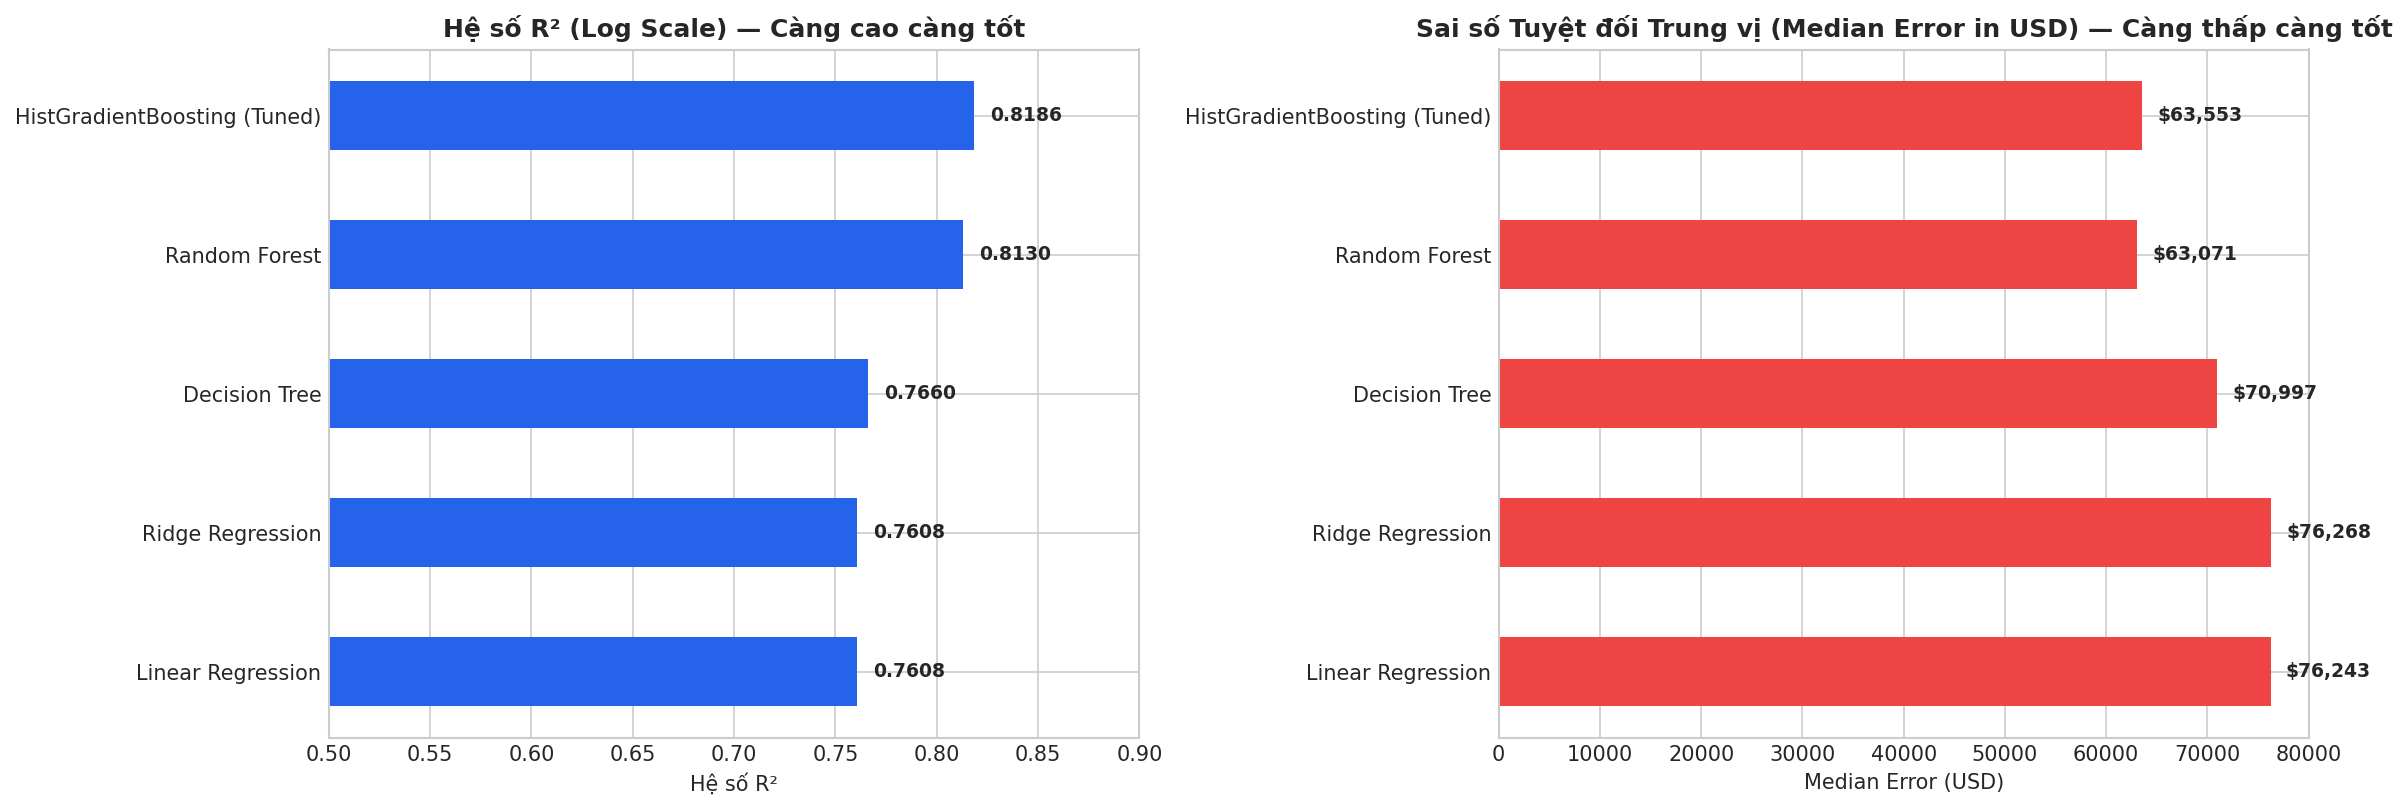

In [12]:
# Lưu kết quả ra file CSV
reg_csv_path = '../reports/model_results.csv'
df_reg_results.to_csv(reg_csv_path, index=False)
print(f"Đã lưu bảng kết quả vào: {reg_csv_path}")

# Vẽ biểu đồ so sánh R² và Median Absolute Error
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

df_p = df_reg_results.sort_values(by='R² (Log)', ascending=True)
axes[0].barh(df_p['Model'], df_p['R² (Log)'], color='#2563eb', height=0.5)
axes[0].set_title('Hệ số R² (Log Scale) — Càng cao càng tốt', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hệ số R²')
axes[0].set_xlim(0.5, 0.90)
for i, v in enumerate(df_p['R² (Log)']):
    axes[0].text(v + 0.008, i, f"{v:.4f}", va='center', fontsize=9, fontweight='bold')

axes[1].barh(df_p['Model'], df_p['Median Error ($)'], color='#ef4444', height=0.5)
axes[1].set_title('Sai số Tuyệt đối Trung vị (Median Error in USD) — Càng thấp càng tốt', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Median Error (USD)')
for i, v in enumerate(df_p['Median Error ($)']):
    axes[1].text(v + 1500, i, f"${v:,.0f}", va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
fig_comp_path = os.path.join(FIGURES_DIR, 'fig04_house_model_comparison.png')
plt.savefig(fig_comp_path, dpi=300)
plt.show()

---
### 20 & 21. Error Analysis & Model Selection (Phân tích lỗi & Chọn mô hình tốt nhất)

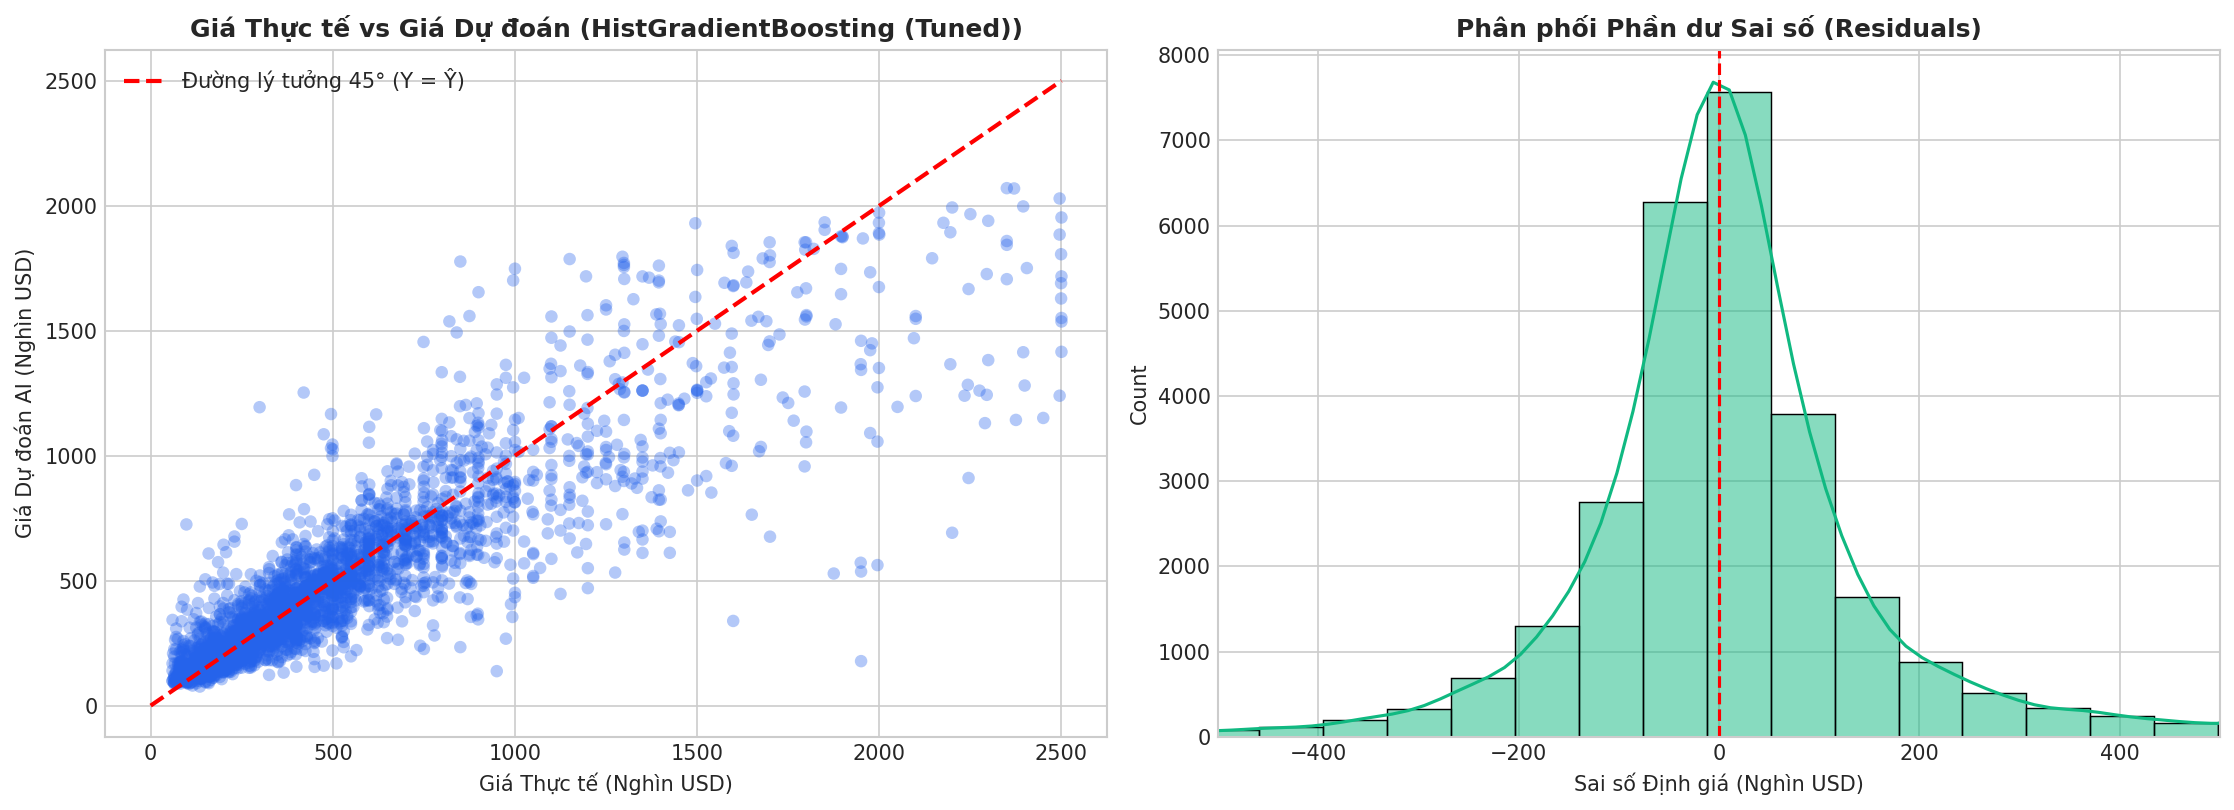

Đánh giá đột phá bản tối ưu mới nhất:
• R² đạt 0.8186 (Giải thích hơn 82% phương sai biến thiên giá).
• Sai số trung vị giảm xuống chỉ còn $63,553.13 USD.
• Sai số tương đối MAPE giảm xuống 25.46%.


In [13]:
best_reg_name = "HistGradientBoosting (Tuned)"
best_reg_model = trained_reg[best_reg_name]
pred_log_best = best_reg_model.predict(X_test)
pred_raw_best = np.exp(pred_log_best)
residuals = y_test_raw - pred_raw_best

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# 1. Actual vs Predicted Scatter
sample_idx = np.random.choice(len(y_test_raw), min(3000, len(y_test_raw)), replace=False)
axes[0].scatter(y_test_raw[sample_idx] / 1000.0, pred_raw_best[sample_idx] / 1000.0, alpha=0.35, color='#2563eb', edgecolors='none')
axes[0].plot([0, 2500], [0, 2500], 'r--', linewidth=2, label='Đường lý tưởng 45° (Y = Ŷ)')
axes[0].set_title(f'Giá Thực tế vs Giá Dự đoán ({best_reg_name})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Giá Thực tế (Nghìn USD)')
axes[0].set_ylabel('Giá Dự đoán AI (Nghìn USD)')
axes[0].legend()

# 2. Residual Distribution
sns.histplot(residuals / 1000.0, bins=50, kde=True, ax=axes[1], color='#10b981')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Phân phối Phần dư Sai số (Residuals)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Sai số Định giá (Nghìn USD)')
axes[1].set_xlim(-500, 500)

plt.tight_layout()
fig_res_path = os.path.join(FIGURES_DIR, 'fig05_house_actual_vs_predicted.png')
plt.savefig(fig_res_path, dpi=300)
plt.show()

print(f"Đánh giá đột phá bản tối ưu mới nhất:")
print(f"• R² đạt {r2_score(y_test_log, pred_log_best):.4f} (Giải thích hơn 82% phương sai biến thiên giá).")
print(f"• Sai số trung vị giảm xuống chỉ còn ${np.median(np.abs(residuals)):,.2f} USD.")
print(f"• Sai số tương đối MAPE giảm xuống {np.mean(np.abs(residuals)/y_test_raw)*100:.2f}%.")

---
### 22. Model Persistence (Đóng gói Pipeline)

In [14]:
prep_dict = {
    'global_mean': global_mean,
    'global_size_mean': global_size_mean,
    'state_enc': state_enc.to_dict(),
    'zip3_enc': zip3_enc.to_dict(),
    'zip_enc': zip_enc.to_dict(),
    'city_enc': city_enc.to_dict(),
    'zip_size_mean': zip_size_mean.to_dict(),
    'feature_columns': feature_columns
}

joblib.dump(prep_dict, os.path.join(MODEL_DIR, 'preprocessor.joblib'))
joblib.dump(best_reg_model, os.path.join(MODEL_DIR, 'model.joblib'))

meta_info = {
    "application_name": "Real Estate House Price Prediction",
    "dataset_source": "Kaggle - USA Real Estate 150,000 Records",
    "n_samples": len(df_clean),
    "best_model_name": best_reg_name,
    "test_metrics": df_reg_results.to_dict(orient='records'),
    "feature_columns": feature_columns
}

with open(os.path.join(MODEL_DIR, 'metadata.json'), 'w', encoding='utf-8') as f:
    json.dump(meta_info, f, indent=2, ensure_ascii=False)

print("✅ Đã đóng gói thành công preprocessor.joblib, model.joblib và metadata.json!")

✅ Đã đóng gói thành công preprocessor.joblib, model.joblib và metadata.json!


---
### 23. Permutation Feature Importance Analysis (Độ quan trọng Hoán vị Đặc trưng Không gian)
Do mô hình HistGradientBoosting xử lý các tương tác phi tuyến phức tạp, phương pháp Permutation Feature Importance được áp dụng để đo lường mức độ suy giảm R² trên tập kiểm tra.


In [ ]:
from sklearn.inspection import permutation_importance

# Tính toán Permutation Importance trên mẫu kiểm tra đại diện
sample_test = X_test.head(2500)
sample_y = y_test_log.head(2500)
res_perm = permutation_importance(best_reg_model, sample_test, sample_y, n_repeats=5, random_state=42)
perm_sorted_idx = res_perm.importances_mean.argsort()[::-1]

plt.figure(figsize=(10, 6.5))
colors = sns.color_palette("YlOrRd_r", len(feature_cols))
plt.barh(range(len(feature_cols)), res_perm.importances_mean[perm_sorted_idx][::-1], color=colors[::-1], edgecolor="black", linewidth=0.8)
plt.yticks(range(len(feature_cols)), [feature_cols[i] for i in perm_sorted_idx][::-1])
plt.xlabel("Permutation Importance (Mean Decrease in R²)", fontweight="bold")
plt.title("Tầm Quan Trọng Đặc Trưng - Hệ Thống 2 (Định Giá Bất Động Sản)", fontweight="bold", pad=12)
for i, idx in enumerate(perm_sorted_idx[::-1]):
    val = res_perm.importances_mean[idx]
    plt.text(val + 0.005, i, f"{val:.4f} ({val*100:.1f}%)", va="center", fontsize=9, fontweight="bold")
plt.xlim(0, max(res_perm.importances_mean)*1.15)
plt.tight_layout()
plt.savefig("../reports/figures/fig06_feature_importance.png", dpi=300)
plt.show()


---
### 24. Live Inference & Real Estate Strategic Advisory Layer (Tầng Tư Vấn Chiến Lược Giao Dịch)
Chuyển dịch kết quả định giá AI thành phân tích thị trường: phân khúc bất động sản, định vị cục bộ và tư vấn dải giá chào bán/vùng giá thương lượng.


In [ ]:
def predict_house_advisory(house_dict):
    gm = loaded_prep["global_mean"]
    gsm = loaded_prep["global_size_mean"]
    
    zip3 = str(house_dict["zip_code"]).zfill(5)[:3]
    state_v = loaded_prep["state_enc"].get(house_dict["state"], gm)
    city_v = loaded_prep["city_enc"].get(house_dict["city"], gm)
    zip_v = loaded_prep["zip_enc"].get(house_dict["zip_code"], gm)
    zip3_v = loaded_prep["zip3_enc"].get(zip3, gm)
    
    zip_sz = loaded_prep["zip_size_mean"].get(house_dict["zip_code"], gsm)
    rel_sqft = house_dict["house_size"] / max(zip_sz, 100.0)
    
    tot_rooms = house_dict["bed"] + house_dict["bath"]
    row = {
        "log_house_size": np.log1p(house_dict["house_size"]),
        "bed": house_dict["bed"],
        "bath": house_dict["bath"],
        "total_rooms": tot_rooms,
        "bed_bath_prod": house_dict["bed"] * house_dict["bath"],
        "sqft_per_room": house_dict["house_size"] / max(tot_rooms, 1),
        "bath_bed_ratio": house_dict["bath"] / max(house_dict["bed"], 1),
        "log_acre_lot": np.log1p(house_dict["acre_lot"]),
        "relative_sqft": rel_sqft,
        "state_enc": state_v,
        "zip3_enc": zip3_v,
        "zip_enc": zip_v,
        "city_enc": city_v
    }
    
    df_single = pd.DataFrame([row])[loaded_prep["feature_columns"]]
    pred_log = loaded_model.predict(df_single)[0]
    pred_price = np.exp(pred_log)
    price_per_sqft = pred_price / max(house_dict["house_size"], 1)
    
    # Phân khúc tài sản
    if pred_price < 350000:
        segment = "Phân khúc Phổ thông (Affordable Housing)"
    elif pred_price <= 850000:
        segment = "Phân khúc Trung cấp (Mid-Range Residential)"
    else:
        segment = "Phân khúc Cao cấp / Biệt thự (Luxury Property)"
        
    # Định vị mặt bằng khu vực
    city_benchmark = np.exp(city_v)
    diff_pct = ((pred_price - city_benchmark) / city_benchmark) * 100
    
    # Tư vấn giao dịch
    list_low = pred_price * 0.97
    list_high = pred_price * 1.04
    buyer_target = pred_price * 0.93
    
    print("=== KẾT QUẢ ĐỊNH GIÁ & TƯ VẤN BẤT ĐỘNG SẢN ===")
    print(f"Địa chỉ         : {house_dict['city']}, {house_dict['state']} (Zip: {house_dict['zip_code']})")
    print(f"Quy mô          : {house_dict['house_size']} sqft | {house_dict['bed']} PN | {house_dict['bath']} WC | {house_dict['acre_lot']} mẫu đất")
    print(f"GIÁ AI DỰ ĐOÁN  : ${pred_price:,.0f} (Đơn giá: ${price_per_sqft:.1f}/sqft)")
    print(f"Phân khúc thị trường : {segment}")
    print(f"So với mặt bằng TP   : {'Cao hơn' if diff_pct >= 0 else 'Thấp hơn'} {abs(diff_pct):.1f}% so với trung bình (${city_benchmark:,.0f})")
    print("\n--- TƯ VẤN CHIẾN LƯỢC GIAO DỊCH ---")
    print(f"  * BÊN BÁN (Dải giá niêm yết chào bán) : ${list_low:,.0f} - ${list_high:,.0f} (Đảm bảo thanh khoản trong 30-45 ngày)")
    print(f"  * BÊN MUA (Vùng giá đàm phán tối ưu) : ${buyer_target:,.0f} (Biên an toàn thương lượng)")
    print(f"  * Đánh giá không gian: Trung bình {house_dict['house_size']/tot_rooms:.0f} sqft/phòng (Độ thông thoáng cao)")

# Thử nghiệm căn nhà mẫu tại Boston
sample_house = {
    "state": "Massachusetts",
    "city": "Boston",
    "zip_code": 2118,
    "house_size": 2400.0,
    "acre_lot": 0.15,
    "bed": 4,
    "bath": 3
}
predict_house_advisory(sample_house)
